# Задание 4

Предсказание года песни по 90 числовым признакам. Используются только файлы songs-prediction-2026: train_x.csv, train_y.csv и test_x.csv. Обучающая выборка содержит 14 000 песен, тестовая — 6000.
Индексы строк и ID не используются как признаки. Исходный датасет UCI и внешние данные не используются, ансамблирования нет.


In [1]:
from pathlib import Path
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

In [2]:
data_dir = Path("data/year_prediction")
train_x = pd.read_csv(data_dir / "train_x.csv", index_col=0)
train_y = pd.read_csv(data_dir / "train_y.csv", index_col=0).loc[train_x.index, "year"]
test_x = pd.read_csv(data_dir / "test_x.csv").set_index("id")

x = torch.tensor(train_x.to_numpy(), dtype=torch.float32)
y = torch.tensor(train_y.to_numpy(), dtype=torch.float32)
x_test = torch.tensor(test_x[train_x.columns].to_numpy(), dtype=torch.float32)
print(x.shape, y.shape, x_test.shape)

torch.Size([14000, 90]) torch.Size([14000]) torch.Size([6000, 90])


## Предобработка

Train случайно делится на 80% для обучения и 20% для валидации, seed = 42. Средние и стандартные отклонения признаков и года вычисляются только на обучающей части.
Качество измеряется RMSE в годах. Для сравнения считается RMSE константного прогноза среднего года обучающей части.


In [3]:
indices = torch.randperm(len(y), generator=torch.Generator().manual_seed(42))
split = int(0.8 * len(indices))
train_indices, val_indices = indices[:split], indices[split:]

x_mean = x[train_indices].mean(dim=0)
x_std = x[train_indices].std(dim=0).clamp(min=1e-8)
y_mean = y[train_indices].mean()
y_std = y[train_indices].std()

x_train = (x[train_indices] - x_mean) / x_std
x_val = (x[val_indices] - x_mean) / x_std
y_train = (y[train_indices] - y_mean) / y_std
y_val = (y[val_indices] - y_mean) / y_std

train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=256, shuffle=True, drop_last=True)
val_loader = DataLoader(TensorDataset(x_val, y_val), batch_size=512)

baseline_rmse = (y[val_indices] - y_mean).square().mean().sqrt().item()
print(f"Baseline RMSE: {baseline_rmse:.4f}")

Baseline RMSE: 10.8443


## Модель и оптимизаторы

MLP: число признаков → 256 → 128 → 64 → 1. В скрытых слоях используются ReLU, BatchNorm и dropout = 0.1. Выход — непрерывный год после обратной нормализации.
Сравниваются torch.optim.Adam и Adam из третьего задания: lr = 0.001, betas = (0.9, 0.999), eps = 1e-8. Начальные веса и seed обучения одинаковы.


In [4]:
class YearNetwork(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.layers(x).squeeze(1)

In [5]:
class Adam:
    def __init__(self, parameters, lr=0.001, betas=(0.9, 0.999), eps=1e-8):
        self.parameters = list(parameters)
        self.lr = lr
        self.betas = betas
        self.eps = eps
        self.m = [torch.zeros_like(p) for p in self.parameters]
        self.v = [torch.zeros_like(p) for p in self.parameters]
        self.steps = [0] * len(self.parameters)

    def zero_grad(self):
        for p in self.parameters:
            p.grad = None

    @torch.no_grad()
    def step(self):
        beta1, beta2 = self.betas
        for i, p in enumerate(self.parameters):
            if p.grad is None:
                continue
            self.steps[i] += 1
            self.m[i] = beta1 * self.m[i] + (1 - beta1) * p.grad
            self.v[i] = beta2 * self.v[i] + (1 - beta2) * p.grad.square()
            m_hat = self.m[i] / (1 - beta1 ** self.steps[i])
            v_hat = self.v[i] / (1 - beta2 ** self.steps[i])
            p -= self.lr * m_hat / (v_hat.sqrt() + self.eps)

In [6]:
def train_model(model, optimizer, epochs=30):
    criterion = nn.MSELoss()
    history = {"train_rmse": [], "val_rmse": []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        count = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(yb)
            count += len(yb)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                val_loss += (model(xb) - yb).square().sum().item()

        train_rmse = (train_loss / count) ** 0.5 * y_std.item()
        val_rmse = (val_loss / len(val_loader.dataset)) ** 0.5 * y_std.item()
        history["train_rmse"].append(train_rmse)
        history["val_rmse"].append(val_rmse)
        print(f"epoch={epoch + 1} train_rmse={train_rmse:.4f} val_rmse={val_rmse:.4f}")
    return history

In [7]:
optimizers = {
    "Torch Adam": lambda parameters: torch.optim.Adam(parameters, lr=0.001),
    "Custom Adam": lambda parameters: Adam(parameters, lr=0.001)
}

histories = {}
for name, make_optimizer in optimizers.items():
    torch.manual_seed(42)
    model = YearNetwork(x.shape[1])
    optimizer = make_optimizer(model.parameters())
    torch.manual_seed(123)
    print(name)
    histories[name] = train_model(model, optimizer)

Torch Adam


epoch=1 train_rmse=10.0687 val_rmse=9.3666
epoch=2 train_rmse=9.2853 val_rmse=9.1507


epoch=3 train_rmse=8.8799 val_rmse=9.1415
epoch=4 train_rmse=8.5956 val_rmse=9.3110


epoch=5 train_rmse=8.3293 val_rmse=9.2843
epoch=6 train_rmse=8.0867 val_rmse=9.2578


epoch=7 train_rmse=7.8890 val_rmse=9.2382
epoch=8 train_rmse=7.6528 val_rmse=9.3007


...

epoch=21 train_rmse=5.7052 val_rmse=9.6034
epoch=22 train_rmse=5.6486 val_rmse=9.6787


epoch=23 train_rmse=5.4863 val_rmse=9.5794
epoch=24 train_rmse=5.4349 val_rmse=9.5456


epoch=25 train_rmse=5.3822 val_rmse=9.5016
epoch=26 train_rmse=5.3652 val_rmse=9.5827


epoch=27 train_rmse=5.1917 val_rmse=9.6760
epoch=28 train_rmse=5.2415 val_rmse=9.5579


epoch=29 train_rmse=5.2051 val_rmse=9.6745
epoch=30 train_rmse=5.1254 val_rmse=9.5221


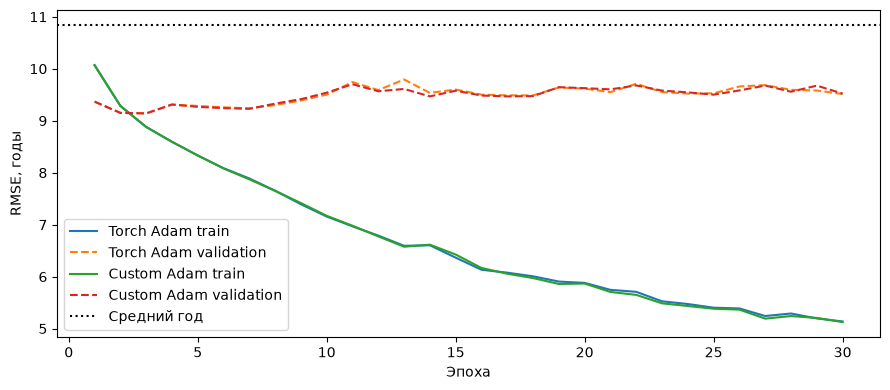

Torch Adam: best_epoch=3, RMSE=9.1415
Custom Adam: best_epoch=3, RMSE=9.1405


In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
for name, history in histories.items():
    epochs = range(1, len(history["val_rmse"]) + 1)
    ax.plot(epochs, history["train_rmse"], label=f"{name} train")
    ax.plot(epochs, history["val_rmse"], linestyle="--", label=f"{name} validation")
ax.axhline(baseline_rmse, color="black", linestyle=":", label="Средний год")
ax.set_xlabel("Эпоха")
ax.set_ylabel("RMSE, годы")
ax.legend()
plt.tight_layout()
plt.show()

for name, history in histories.items():
    best_epoch = min(range(len(history["val_rmse"])), key=lambda i: history["val_rmse"][i]) + 1
    print(f"{name}: best_epoch={best_epoch}, RMSE={min(history['val_rmse']):.4f}")

## Финальное обучение и submission

Для собственного Adam выбирается число эпох с минимальным RMSE на валидации. Затем одна новая модель обучается на всём train столько же эпох. Нормализация заново вычисляется по всему train; test используется только для предсказания.
Годы не округляются, порядок ID соответствует строкам test_x.csv.


In [9]:
custom_history = histories["Custom Adam"]["val_rmse"]
final_epochs = min(range(len(custom_history)), key=lambda i: custom_history[i]) + 1

x_mean = x.mean(dim=0)
x_std = x.std(dim=0).clamp(min=1e-8)
y_mean = y.mean()
y_std = y.std()

x_full = (x - x_mean) / x_std
x_test_scaled = (x_test - x_mean) / x_std
y_full = (y - y_mean) / y_std
full_loader = DataLoader(TensorDataset(x_full, y_full), batch_size=256, shuffle=True, drop_last=True)

torch.manual_seed(42)
model = YearNetwork(x.shape[1])
optimizer = Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
torch.manual_seed(123)
model.train()

for epoch in range(final_epochs):
    total_loss = 0
    count = 0
    for xb, yb in full_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)
        count += len(yb)
    print(f"epoch={epoch + 1} train_rmse={(total_loss / count) ** 0.5 * y_std.item():.4f}")

epoch=1 train_rmse=9.9418


epoch=2 train_rmse=9.1596


epoch=3 train_rmse=8.8639


In [10]:
test_loader = DataLoader(TensorDataset(x_test_scaled), batch_size=512)
model.eval()
predictions = []
with torch.no_grad():
    for (xb,) in test_loader:
        predictions.append(model(xb) * y_std + y_mean)
predictions = torch.cat(predictions).numpy()

submission = pd.DataFrame({"id": test_x.index, "year": predictions})
submission.to_csv("submission.csv", index=False)
submission.head()

,id,year
0,3416,2000.323242
1,18991,2003.540161
2,11105,1996.389526
3,18902,2000.521973
4,18958,2000.271729


## Результаты

Валидация содержит 2800 песен, обучающая часть — 11 200. RMSE измеряется в годах.

| Модель | Лучший RMSE на валидации | Эпоха |
|---|---:|---:|
| Средний год обучающей части | 10.8443 | — |
| Torch Adam | 9.1415 | 3 |
| Custom Adam | 9.1405 | 3 |

MLP снижает RMSE относительно среднего года на 1.7038 года, примерно на 15.7%. Собственный Adam даёт практически тот же результат, что и встроенный: разница лучших RMSE равна 0.0010 года.

После первых эпох train RMSE продолжает снижаться, а validation RMSE растёт: модель переобучается. Для финального обучения выбраны 3 эпохи по валидации собственного Adam.

Финальная модель заново обучена собственным Adam на полном train. Создан submission.csv с 6000 прогнозами, колонками id и year и ID из test_x.csv. Годы оставлены непрерывными. В архиве нет sample_submission, поэтому имена колонок взяты из test_x.csv и train_y.csv.

Оценка Kaggle не получена: здесь приведено качество на локальной валидации. Файл готов для отправки в соревнование.

Источники: [учебное соревнование](https://www.kaggle.com/competitions/songs-prediction-2026), [описание признаков](https://archive.ics.uci.edu/dataset/203/yearpredictionmsd), [Adam](https://arxiv.org/abs/1412.6980).
